# NLP Project 1: Customer Review Analysis

**Problem:** An online shopping company needs to analyze thousands of customer reviews to understand customer satisfaction, product quality, delivery, and service. Manually reading all reviews is too slow. They need an automated system to find positive/negative opinions, common issues, and useful business insights.

## Key Tasks:
1.  Collect review data.
2.  Clean and prepare text.
3.  Perform sentiment analysis.
4.  Identify frequent keywords and complaints.
5.  Generate business insights.

Step 1:Import Required libraries

In [ ]:
import pandas as pd #loading data
import numpy as np  #for mathematical calculations
import re  #regular expressions -for cleaning the data
import nltk  # for basic
import matplotlib.pyplot as plt #visulization
from nltk.corpus import stopwords
#what is corpus? collection of documents . Collection of words is sentence , collection of sentence is paragraph .
#what is stopwords? to remove be verbs unwanted words .
from nltk.tokenize import word_tokenize  #splitting the words into units
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud


# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')  #for sentimentanalysis we are using this.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Step 2:Create Sample Customer Reviews

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

#display first few rows
print("Customer Reviews Dataset")
print(df.head())


Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


step 3 :data cleaning and preporcessing

In [ ]:
stop_words=set(stopwords.words('english'))
#stopwords are unnessary words

#for cleaning,input is text.
#why we are converting to lowercase :python is case sensitive .

def clean_text(text):
  #convert to lowercase
  text=text.lower()
  print('lower case',text)

  #remove spl characters and numbers
  text=re.sub(r'[^a-zA-Z\s]','',text)
  print('spl character',text)

  #tokenization
  words=word_tokenize(text)
  print('tokenization',words)

  #remove stopwords
  words=[word for word in words if word not in stop_words]
  print('stopwords',words)

  #Join words again
  cleaned_text=" ".join(words)

  return cleaned_text

#Apply cleaning function
df['Cleaned_Review']=df['Review'].apply(clean_text)
print("\nCleaned Reviews:")
print(df[['Review','Cleaned_Review']])


lower case the product quality is excellent and delivery was very fast.
spl character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
spl character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
spl character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
spl character the delivery was delayed and support team did not respond
tokenization ['the', 'delivery', 'was', 'delaye

In [ ]:
clean_text("The product quality is excellent and delivery was very")

lower case the product quality is excellent and delivery was very
spl character the product quality is excellent and delivery was very
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very']
stopwords ['product', 'quality', 'excellent', 'delivery']


'product quality excellent delivery'

Step 4:Sentiment Analysis

In [ ]:
sia= SentimentIntensityAnalyzer()

def analyze_sentiment(review):
  score=sia.polarity_scores(review)
  compound =score['compound']

  if compound>=0.05:
    return "Positive"
  elif compound<=-0.05:
    return "Negative"
  else:
    return "Neutral"

#apply sentiment analysis
df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)
print("\nSentiment Analysis Results:")
print(df[['Review','Sentiment']])




Sentiment Analysis Results:
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


Step 5:Find Common keywords

In [ ]:
all_words=" ".join(df['Cleaned_Review'])
word_list=all_words.split()

#count word frequency
word_freq=Counter(word_list)

#display top 10 keywords
print("\n Top 10 common keywords")
print(word_freq.most_common(10))


 Top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


step 6: Identify common complaints

In [ ]:
negative_reviews=df[df['Sentiment']=='Negative']
negative_words=" ".join(negative_reviews['Cleaned_Review'])
negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)

print("\n Most Common Complaint Keywords")
print(complaint_freq.most_common(10))


 Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


STEP 7:Visulization- Sentiment Count

In [ ]:
sentiment_counts=df['Sentiment'].value_counts()  #it will give categories count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


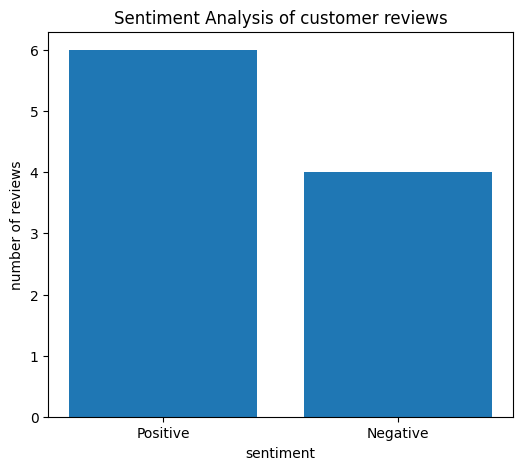

In [ ]:
sentiment_counts=df['Sentiment'].value_counts()  #it will give categories count
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.title('Sentiment Analysis of customer reviews')
plt.xlabel('sentiment')
plt.ylabel('number of reviews')
plt.show()

step 8: Generate word cloud

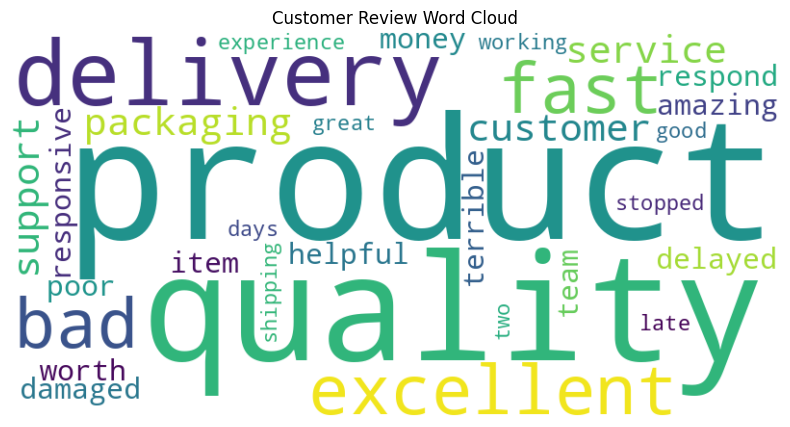

In [ ]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()